Loading Dataset

In [ ]:
# Upload kaggle.json
from google.colab import files
files.upload()

# Setup Kaggle CLI
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

# Unzip dataset
!unzip brain-tumor-mri-dataset.zip -d ./brain_tumor_dataset


Streaming output truncated to the last 5000 lines.
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0712.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0713.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0714.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0715.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0716.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0717.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0718.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0719.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0720.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0721.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0722.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0723.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0724.jpg  
  inflating: ./brain_tumor_dataset/Training/glioma/Tr-gl_0725.jpg

#Visualize Dataset

['Training', 'Testing']


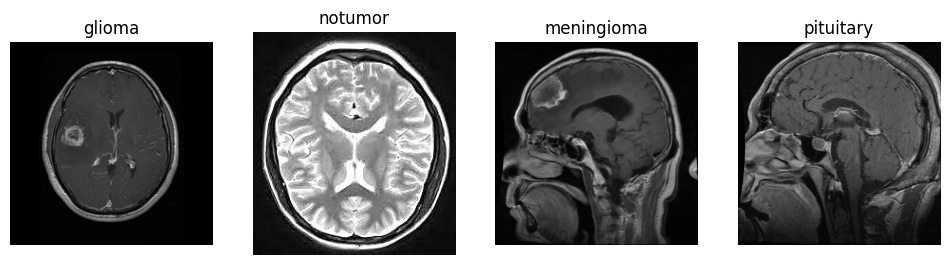

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Check folder structure
data_dir = './brain_tumor_dataset'
print(os.listdir(data_dir))

# Visualize few images
classes = os.listdir(data_dir + '/Training') # Look inside the Training directory
plt.figure(figsize=(12,6))
for i, cls in enumerate(classes):
    class_dir = os.path.join(data_dir, 'Training', cls) # Corrected path
    # Iterate through items in the class directory to find an image file
    for item in os.listdir(class_dir):
        item_path = os.path.join(class_dir, item)
        if os.path.isfile(item_path): # Check if the item is a file
            try:
                img = mpimg.imread(item_path)
                plt.subplot(1, 4, i + 1)
                plt.imshow(img, cmap='gray')
                plt.title(cls)
                plt.axis('off')
                break # Display only the first image found and move to the next class
            except Exception as e:
                print(f"Could not read image file {item_path}: {e}")
                continue # Continue to the next item if reading fails
plt.show()

#Load And Preprocess

In [ ]:
import tensorflow as tf

data_dir = 'brain_tumor_dataset/Training'

batch_size = 32
img_size = (224, 224)

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


#Data Augmentation

In [ ]:
from tensorflow.keras import layers

AUTOTUNE = tf.data.AUTOTUNE

# Normalize pixel values to [0,1]
normalization_layer = layers.Rescaling(1./255)

aug_layer = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1)
])


# Apply preprocessing
train_ds = train_ds.map(lambda x, y: (normalization_layer(aug_layer(x)), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)


#Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute balanced class weights
y_true_all = np.concatenate([y.numpy() for x, y in train_ds], axis=0)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_true_all),
                                     y=y_true_all)
class_weights = dict(enumerate(class_weights))
print("Computed class weights:", class_weights)

# 👉 Force model to care more about meningioma (index 1)
class_weights[1] *= 1.3
print("Adjusted class weights:", class_weights)


Computed class weights: {0: np.float64(1.0608170844939646), 1: np.float64(1.048165137614679), 2: np.float64(0.9161988773055333), 3: np.float64(0.9883217993079585)}
Adjusted class weights: {0: np.float64(1.0608170844939646), 1: np.float64(1.3626146788990827), 2: np.float64(0.9161988773055333), 3: np.float64(0.9883217993079585)}


#Model Training

In [ ]:
#INCEPTIONV3
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import models, layers

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False
from tensorflow.keras import Model, Input

inputs = Input(shape=(224,224,3))  # 🪄 CHANGE: explicit input
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model_inception = Model(inputs, outputs)

model_inception.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_inception.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         8,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,810,980 (83.20 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_inception = model_inception.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,  # try longer
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step - accuracy: 0.8033 - loss: 0.5579 - val_accuracy: 0.8126 - val_loss: 0.4615
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.7983 - loss: 0.5836 - val_accuracy: 0.8275 - val_loss: 0.4530
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.7999 - loss: 0.5815 - val_accuracy: 0.8336 - val_loss: 0.4474
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.8050 - loss: 0.5758 - val_accuracy: 0.8354 - val_loss: 0.4333
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.8022 - loss: 0.5660 - val_accuracy: 0.8222 - val_loss: 0.4442
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.8109 - loss: 0.5485 - val_accuracy: 0.8292 - val_loss: 0.4550
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.8102 - loss: 0.5557 - val_accuracy: 0.8240 - val_loss: 0.4483


#Fine tune

In [ ]:
# Unfreeze last 150 layers
base_model.trainable = True
for layer in base_model.layers[:-150]:
    layer.trainable = False

model_inception.compile(optimizer=tf.keras.optimizers.Adam(1e-6),  # lower LR
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# train longer
history_finetune = model_inception.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 89s 336ms/step - accuracy: 0.4569 - loss: 1.7133 - val_accuracy: 0.7750 - val_loss: 0.6312
Epoch 2/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.5240 - loss: 1.3978 - val_accuracy: 0.7356 - val_loss: 0.6837
Epoch 3/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.5876 - loss: 1.1649 - val_accuracy: 0.7513 - val_loss: 0.6433
Epoch 4/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.6383 - loss: 0.9888 - val_accuracy: 0.7820 - val_loss: 0.5934
Epoch 5/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.6858 - loss: 0.8759 - val_accuracy: 0.8012 - val_loss: 0.5610
Epoch 6/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.7322 - loss: 0.7693 - val_accuracy: 0.8074 - val_loss: 0.5376
Epoch 7/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.7642 - loss: 0.6613 - val_accuracy: 0.8100 - val_loss: 0.5220
Epoch 8/15
143/143 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - accuracy: 0.8026 - loss: 0

Evaluation

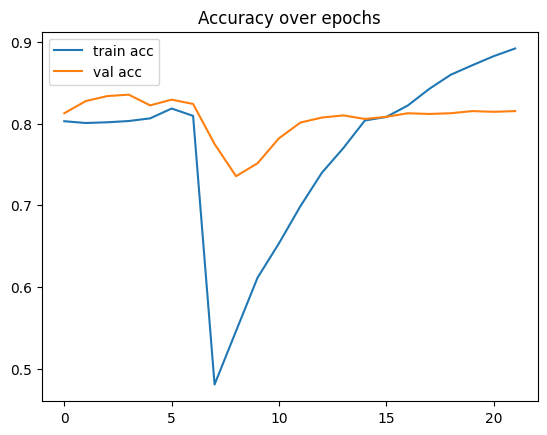

36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step
              precision    recall  f1-score   support

      glioma       0.85      0.78      0.81       244
  meningioma       0.74      0.55      0.63       249
     notumor       0.94      0.89      0.91       348
   pituitary       0.73      0.97      0.83       301

    accuracy                           0.82      1142
   macro avg       0.81      0.80      0.80      1142
weighted avg       0.82      0.82      0.81      1142



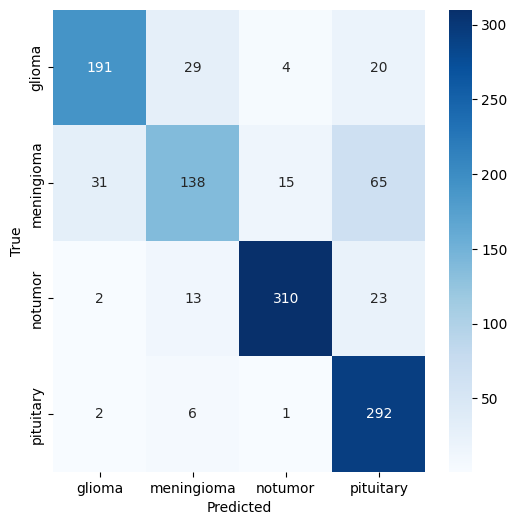

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Plot accuracy
plt.figure()
plt.plot(history_inception.history['accuracy'] + history_finetune.history['accuracy'], label='train acc')
plt.plot(history_inception.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

# Confusion matrix
y_pred = np.argmax(model_inception.predict(val_ds), axis=1)
y_true = np.concatenate([y for x, y in val_ds], axis=0)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
model_inception.save('brain_tumor_inceptionv3.keras')  # 🪄 CHANGE

# Save class names
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
from google.colab import files
files.download('brain_tumor_inceptionv3.keras')  # 🪄 CHANGE
files.download('class_names.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
print(tf.__version__)


2.18.0
